# Give Me Some Credit

## Import libraries, functions and data

In [171]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import numpy as np
import jax
import jax.numpy as jnp

from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression


from google.colab import drive

In [172]:
def plot_roc_curve(fpr, tpr, label="ROC Curve"):
    plt.figure(figsize=(6, 6))

    plt.plot(fpr, tpr, label=label)
    plt.plot([0, 1], [0, 1], color='red', linestyle='--')

    plt.axis([0, 1, 0, 1])
    plt.xlabel("False Positive Rate (1 - SPECIFICITY)")
    plt.ylabel("True Positive Rate (SENSITIVITY)")
    plt.title(label)

    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

In [173]:

path = "/content/drive/MyDrive/Colab Notebooks/NAML/Project/data/"

train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

## Exploratory data analysis

In [174]:
train_df.head()

,Id,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
1,2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
2,3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
3,4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0
4,5,0,0.213179,74,0,0.375607,3500.0,3,0,1,0,1.0


In [175]:
test_df.head()

,Id,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,0,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,9,0.189169,57,0,0.606291,23684.0,9,0,4,0,2.0
2,17,0.166284,53,0,0.188274,8800.0,7,0,0,0,0.0
3,18,0.221813,43,0,0.527888,3280.0,7,0,1,0,2.0
4,24,0.046560,58,0,0.241622,2416.0,9,0,1,0,0.0


In [176]:
train_df.rename(columns={'Unnamed: 0':'ID'}, inplace=True)
test_df.rename(columns={'Unnamed: 0':'ID'}, inplace=True)

In [177]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104805 entries, 0 to 104804
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Id                                    104805 non-null  int64  
 1   SeriousDlqin2yrs                      104805 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  104805 non-null  float64
 3   age                                   104805 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  104805 non-null  int64  
 5   DebtRatio                             104805 non-null  float64
 6   MonthlyIncome                         84024 non-null   float64
 7   NumberOfOpenCreditLinesAndLoans       104805 non-null  int64  
 8   NumberOfTimes90DaysLate               104805 non-null  int64  
 9   NumberRealEstateLoansOrLines          104805 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  104805 non-null  int64  
 11  

In [178]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45195 entries, 0 to 45194
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Id                                    45195 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  45195 non-null  float64
 2   age                                   45195 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  45195 non-null  int64  
 4   DebtRatio                             45195 non-null  float64
 5   MonthlyIncome                         36245 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       45195 non-null  int64  
 7   NumberOfTimes90DaysLate               45195 non-null  int64  
 8   NumberRealEstateLoansOrLines          45195 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  45195 non-null  int64  
 10  NumberOfDependents                    44020 non-null  float64
dtypes: float64(4), 

In [179]:
train_df.describe().round(decimals=2)

,Id,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,104805.00,104805.00,104805.00,104805.00,104805.00,104805.00,84024.00,104805.00,104805.00,104805.00,104805.00,102056.00
mean,75013.71,0.07,5.60,52.35,0.42,354.86,6684.45,8.45,0.26,1.02,0.24,0.76
std,43324.04,0.25,217.39,14.77,4.14,2169.18,15653.13,5.13,4.12,1.14,4.10,1.11
min,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,37508.00,0.00,0.03,41.00,0.00,0.18,3400.00,5.00,0.00,0.00,0.00,0.00
50%,74931.00,0.00,0.15,52.00,0.00,0.37,5400.00,8.00,0.00,1.00,0.00,0.00
75%,112620.00,0.00,0.56,63.00,0.00,0.87,8250.00,11.00,0.00,2.00,0.00,1.00
max,149999.00,1.00,29110.00,109.00,98.00,329664.00,3008750.00,58.00,98.00,54.00,98.00,13.00


In [180]:
test_df.describe().round(decimals=2)

,Id,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,45195.00,45195.00,45195.00,45195.00,45195.00,36245.00,45195.00,45195.00,45195.00,45195.00,44020.00
mean,74966.55,7.08,52.17,0.43,348.70,6637.23,8.45,0.28,1.02,0.25,0.76
std,43249.36,312.15,14.78,4.31,1694.46,10890.05,5.19,4.29,1.11,4.28,1.12
min,0.00,0.00,21.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,37484.50,0.03,41.00,0.00,0.18,3416.00,5.00,0.00,0.00,0.00,0.00
50%,75168.00,0.15,52.00,0.00,0.37,5400.00,8.00,0.00,1.00,0.00,0.00
75%,112194.50,0.56,62.00,0.00,0.87,8224.00,11.00,0.00,2.00,0.00,1.00
max,149997.00,50708.00,109.00,98.00,220516.00,1072500.00,57.00,98.00,29.00,98.00,20.00


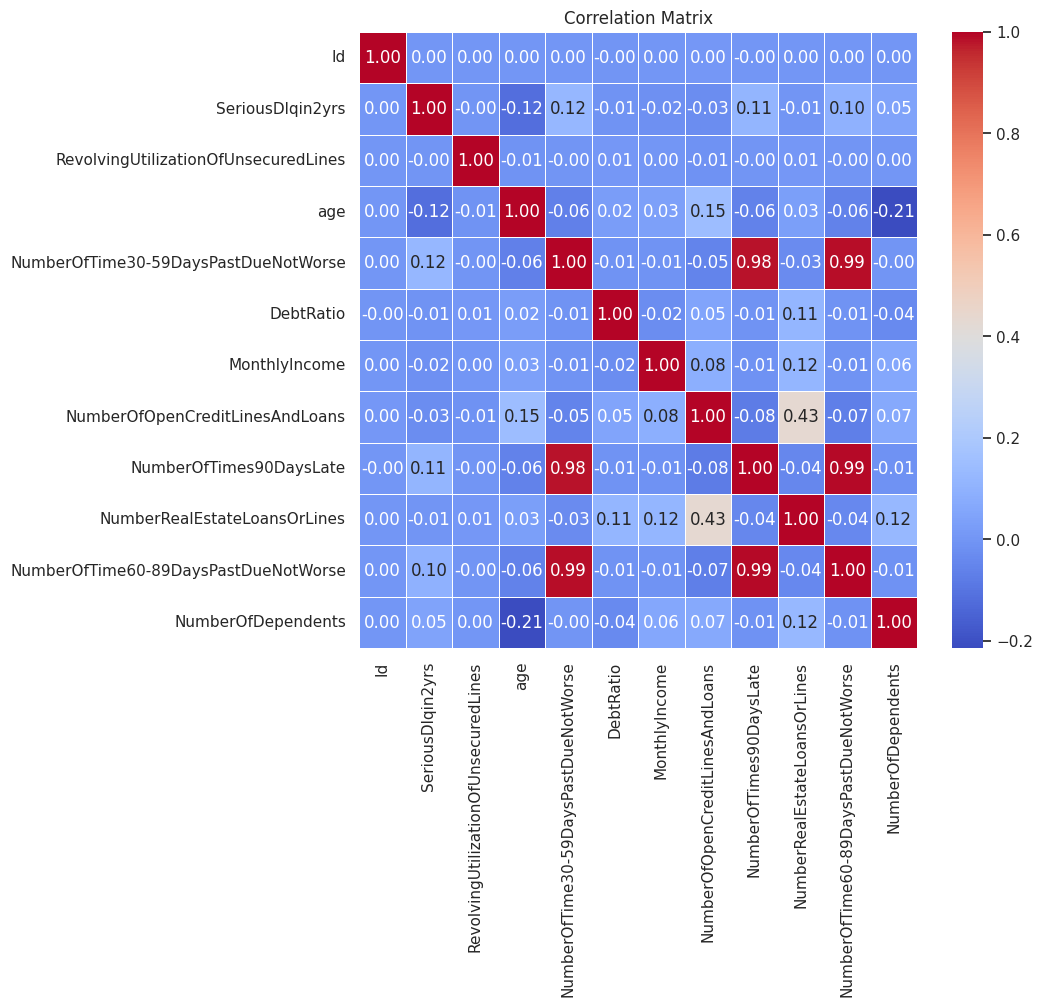

In [181]:
corr = train_df.corr()
fig = plt.figure(figsize=(9,8))
plt.title('Correlation Matrix')
ax = sns.heatmap(corr, annot=True, fmt='.2f', cmap="coolwarm", linewidths=0.5)
plt.show()

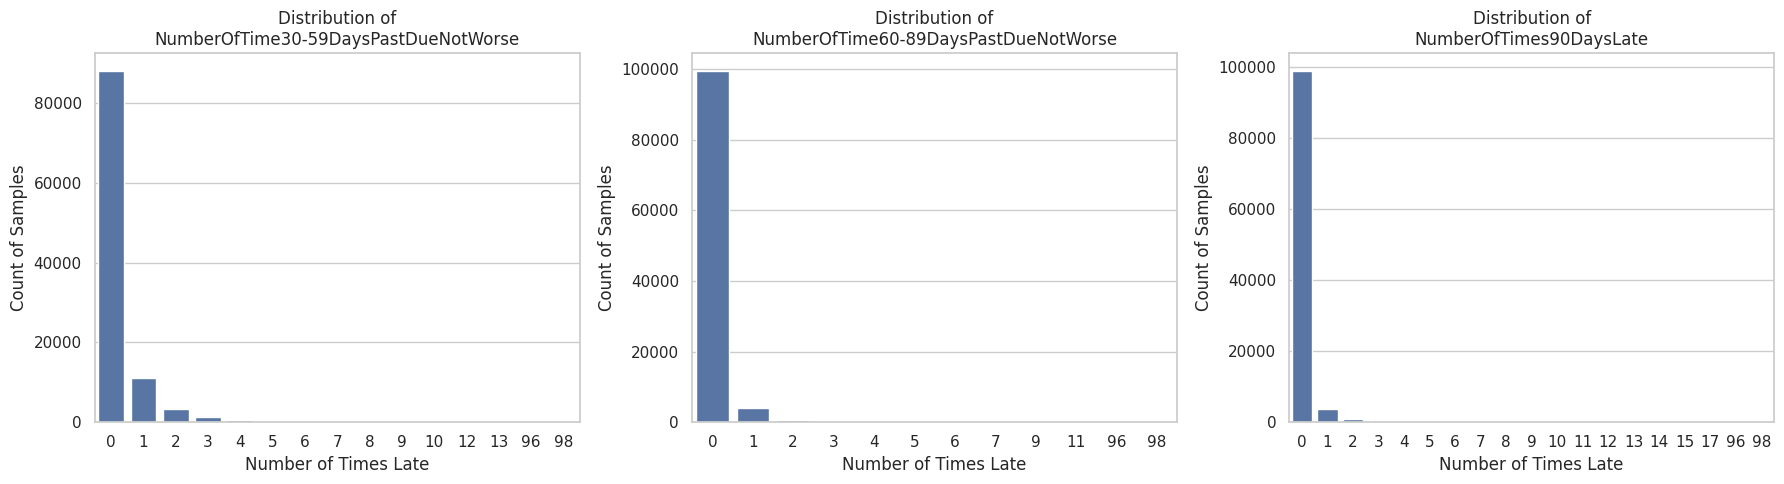

In [182]:
late_cols = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate'
]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(late_cols):
    sns.countplot(
        data=train_df,
        x=col,
        ax=axes[i]
    )
    axes[i].set_title(f'Distribution of\n{col}')
    axes[i].set_xlabel('Number of Times Late')
    axes[i].set_ylabel('Count of Samples')
plt.tight_layout()
plt.show()

In [183]:
count_age_zero = (train_df['age'] == 0).sum()
print(f"Number of samples with age = 0: {count_age_zero}")

Number of samples with age = 0: 1


In [184]:
wrong_mask = (train_df[late_cols[0]].isin([96, 98])) | \
             (train_df[late_cols[1]].isin([96, 98])) | \
             (train_df[late_cols[2]].isin([96, 98]))
wrong_samples = train_df[wrong_mask]

combinations_table = wrong_samples[late_cols].value_counts().reset_index(name='Count')
# wrong_samples[late_cols]: filtered dataset with corrupted rows only
# .value_counts(): it looks for rows that has the same three numbers and counts how many times that combination appears
# .reset_index(name='Count'): it flattens the .value_counts() output into a standard dataframe

print("There are " + str(len(wrong_samples)) + " corrupted samples:")
combinations_table.style.hide(axis="index")

There are 183 corrupted samples:


NumberOfTime30-59DaysPastDueNotWorse,NumberOfTime60-89DaysPastDueNotWorse,NumberOfTimes90DaysLate,Count
98,98,98,181
96,96,96,2


In [185]:
print(train_df.duplicated().value_counts())
print(test_df.duplicated().value_counts())
# no duplicated rows (all False)

False    104805
Name: count, dtype: int64
False    45195
Name: count, dtype: int64


In [186]:
mis_val = train_df.isnull().sum()
mis_val_percent = 100 * train_df.isnull().sum() / len(train_df)
mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)
mis_val_table_ren_columns = mis_val_table.rename(
columns = {0 : 'Missing Values', 1 : '% of Total Values'})
mis_val_table_ren_columns = mis_val_table_ren_columns[
    mis_val_table_ren_columns.iloc[:,1] != 0].sort_values(
'% of Total Values', ascending=False).round(1)
print ("There are " + str(mis_val_table_ren_columns.shape[0]) +
      " columns that have missing values:")
mis_val_table_ren_columns

There are 2 columns that have missing values:


,Missing Values,% of Total Values
MonthlyIncome,20781,19.8
NumberOfDependents,2749,2.6


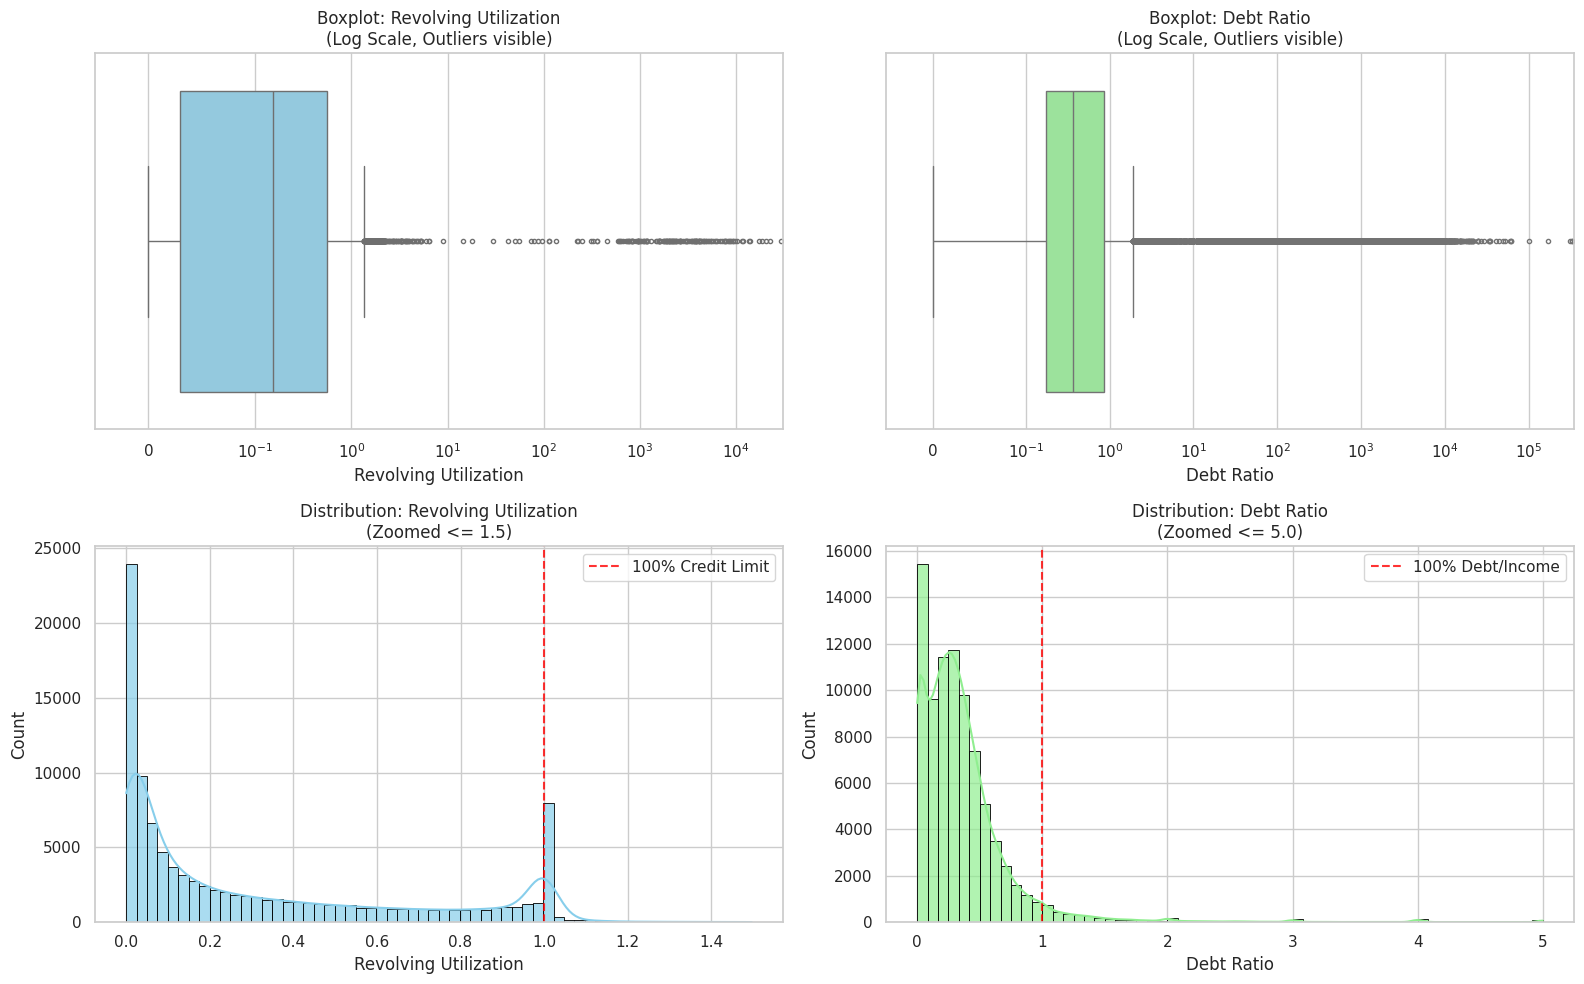

In [187]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Impostiamo un tema globale più pulito e leggibile
sns.set_theme(style="whitegrid")

# Creiamo la griglia 2x2
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# --- RIGA 1: BOXPLOT MIGLIORATI ---
# Manteniamo symlog per vedere gli outlier, ma tagliamo via la parte negativa dell'asse X

sns.boxplot(x=train_df['RevolvingUtilizationOfUnsecuredLines'], ax=axes[0, 0], color='skyblue', fliersize=3)
axes[0, 0].set_title('Boxplot: Revolving Utilization\n(Log Scale, Outliers visible)', fontsize=12)
axes[0, 0].set_xlabel('Revolving Utilization')
axes[0, 0].set_xscale('symlog', linthresh=0.1)
axes[0, 0].set_xlim(left=-0.05) # <-- Questo nasconde i numeri negativi inutili!

sns.boxplot(x=train_df['DebtRatio'], ax=axes[0, 1], color='lightgreen', fliersize=3)
axes[0, 1].set_title('Boxplot: Debt Ratio\n(Log Scale, Outliers visible)', fontsize=12)
axes[0, 1].set_xlabel('Debt Ratio')
axes[0, 1].set_xscale('symlog', linthresh=0.1)
axes[0, 1].set_xlim(left=-0.05) # <-- Come sopra


# --- RIGA 2: ISTOGRAMMI CON LINEE DI RIFERIMENTO ---
# Aggiungiamo più bin, la curva KDE anche al DebtRatio e delle linee rosse tratteggiate
# per indicare visivamente il "limite logico" di 1.0 (100%)

zoom_revolving = train_df[train_df['RevolvingUtilizationOfUnsecuredLines'] <= 1.5]['RevolvingUtilizationOfUnsecuredLines']
sns.histplot(zoom_revolving, bins=60, ax=axes[1, 0], color='skyblue', kde=True, edgecolor='black', alpha=0.7)
# Linea rossa per indicare l'uso del 100% del limite di credito
axes[1, 0].axvline(x=1.0, color='red', linestyle='--', linewidth=1.5, alpha=0.8, label='100% Credit Limit')
axes[1, 0].set_title('Distribution: Revolving Utilization\n(Zoomed <= 1.5)', fontsize=12)
axes[1, 0].set_xlabel('Revolving Utilization')
axes[1, 0].set_ylabel('Count')
axes[1, 0].legend()

zoom_debt = train_df[train_df['DebtRatio'] <= 5.0]['DebtRatio']
sns.histplot(zoom_debt, bins=60, ax=axes[1, 1], color='lightgreen', kde=True, edgecolor='black', alpha=0.7)
# Linea rossa per indicare dove il debito eguaglia esattamente il reddito (100%)
axes[1, 1].axvline(x=1.0, color='red', linestyle='--', linewidth=1.5, alpha=0.8, label='100% Debt/Income')
axes[1, 1].set_title('Distribution: Debt Ratio\n(Zoomed <= 5.0)', fontsize=12)
axes[1, 1].set_xlabel('Debt Ratio')
axes[1, 1].set_ylabel('Count')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# Resettiamo il tema di seaborn al default nel caso ti serva per altri plot
# sns.reset_orig()

In [188]:
wrong_revolving = (train_df['RevolvingUtilizationOfUnsecuredLines'] > 1.0).sum()
print(f"Samples with RevolvingUtilization > 1.0: {wrong_revolving}")


Samples with RevolvingUtilization > 1.0: 2337


In [189]:
wrong_debt = (train_df['DebtRatio'] > 10.0).sum()
print(f"Campioni con DebtRatio > 10.0: {wrong_debt}")
print(train_df['DebtRatio'].quantile(0.99))

Campioni con DebtRatio > 10.0: 20209
5009.0


## Imputing and cleaning

We fix *MonthlyIncome* and *NumberOfDependents*

In [190]:
inc_median = train_df['MonthlyIncome'].median()
dep_median = train_df['NumberOfDependents'].median()
inc_na_mask = train_df['MonthlyIncome'].isna()
train_df['MonthlyIncome'] = train_df['MonthlyIncome'].fillna(inc_median)
train_df['NumberOfDependents'] = train_df['NumberOfDependents'].fillna(dep_median).astype(int)

We fix *age*, *RevolvingUtilizationOfUnsecuredLines*, *DebtRatio*

In [191]:
train_df = train_df[train_df['age'] > 0]
train_df = train_df[train_df['RevolvingUtilizationOfUnsecuredLines'] <= 2.0]
train_df.loc[inc_na_mask, 'DebtRatio'] = train_df.loc[inc_na_mask, 'DebtRatio'] / inc_median

print((train_df['DebtRatio'] > 1000).sum())
#train_df = train_df[train_df['DebtRatio'] <= train_df['DebtRatio'].quantile(0.99)]


700


We fix *NumberOfTime30-59DaysPastDueNotWorse*, *NumberOfTime60-89DaysPastDueNotWorse* and *NumberOfTimes90DaysLate*

In [192]:
for col in late_cols:
    train_df = train_df[~train_df[col].isin([96, 98])]

In [193]:
print(f"New number of training samples: {len(train_df)}")

New number of training samples: 104378


## More data analysis

In [194]:
train_df.describe().round(decimals=2)

,Id,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,104378.00,104378.00,104378.00,104378.00,104378.00,104378.00,104378.00,104378.00,104378.00,104378.00,104378.00,104378.00
mean,75006.38,0.07,0.32,52.39,0.25,21.96,6432.70,8.48,0.09,1.02,0.06,0.74
std,43327.30,0.25,0.35,14.75,0.70,412.76,14051.11,5.12,0.48,1.14,0.33,1.10
min,1.00,0.00,0.00,21.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,37492.25,0.00,0.03,41.00,0.00,0.12,3900.00,5.00,0.00,0.00,0.00,0.00
50%,74930.50,0.00,0.15,52.00,0.00,0.28,5400.00,8.00,0.00,1.00,0.00,0.00
75%,112612.75,0.00,0.55,63.00,0.00,0.48,7400.00,11.00,0.00,2.00,0.00,1.00
max,149999.00,1.00,2.00,109.00,13.00,61106.50,3008750.00,58.00,17.00,54.00,11.00,13.00


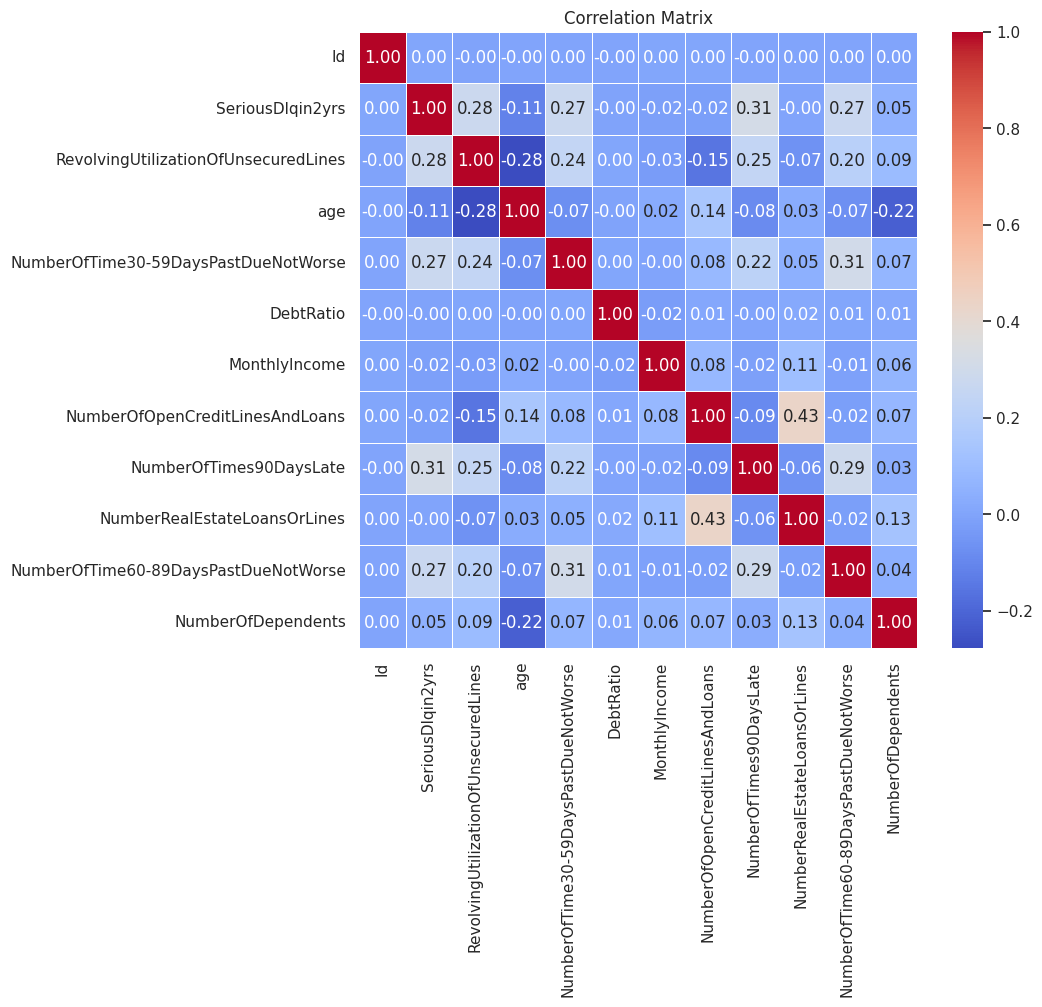

In [195]:
corr = train_df.corr()
fig = plt.figure(figsize=(9,8))
plt.title('Correlation Matrix')
ax = sns.heatmap(corr, annot=True, fmt='.2f', cmap="coolwarm", linewidths=0.5)
plt.show()

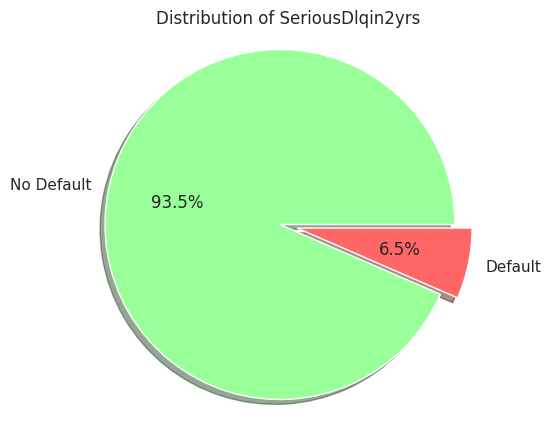

In [196]:
target_counts = train_df['SeriousDlqin2yrs'].value_counts()

plt.figure(figsize=(5, 5))
plt.pie(
    target_counts,
    labels=['No Default', 'Default'],
    autopct='%1.1f%%', # it automatically computes percentages
    colors=['#99ff99', '#ff6666'],
    explode=(0, 0.1), # highlight the Default slice
    shadow=True
)
plt.title('Distribution of SeriousDlqin2yrs')
plt.axis('equal')
plt.show()

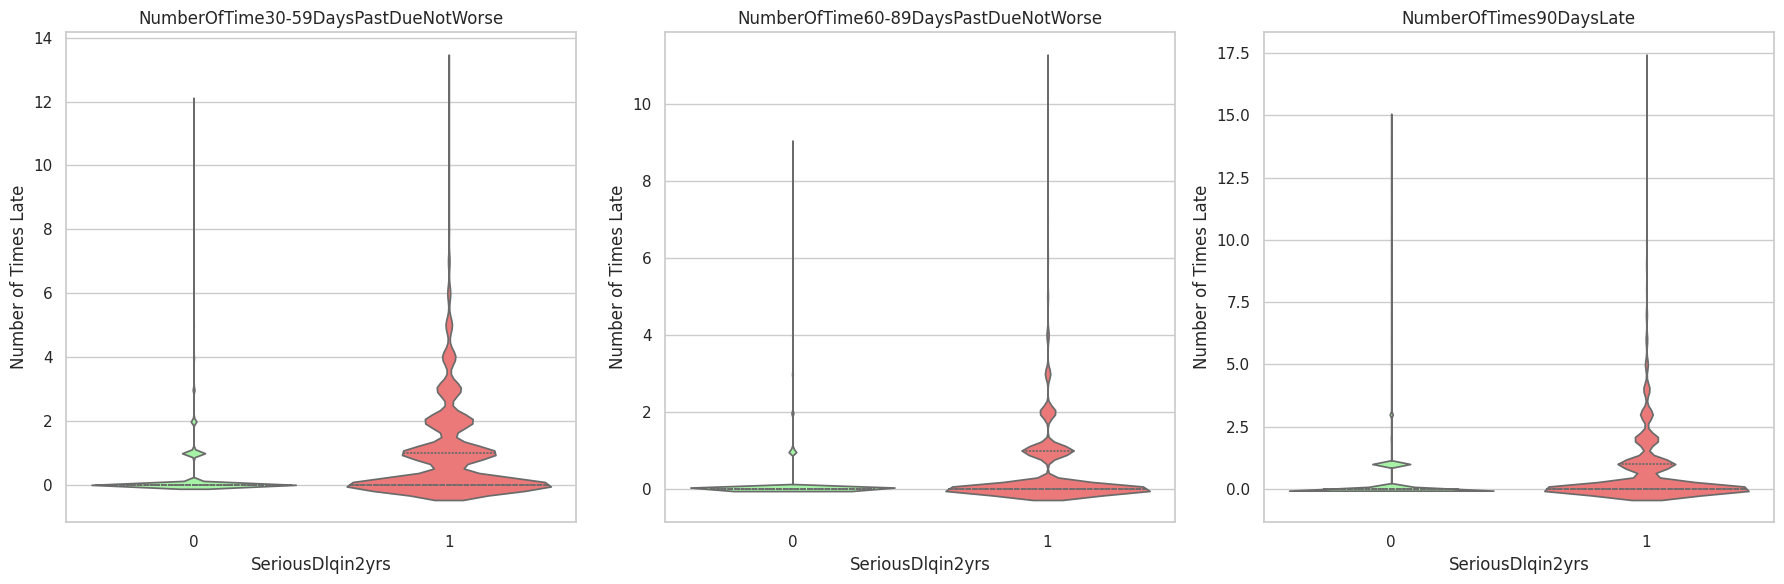

In [197]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, feature in enumerate(late_cols):
    sns.violinplot(
        data=train_df,
        x='SeriousDlqin2yrs',
        y=feature,
        ax=axes[i],
        hue='SeriousDlqin2yrs',
        palette=['#99ff99', '#ff6666'],
        inner='quartile',
        legend=False
    )
    axes[i].set_title(feature)
    axes[i].set_xlabel('SeriousDlqin2yrs')
    axes[i].set_ylabel('Number of Times Late')
plt.tight_layout()
plt.show()

In [198]:
# add some other visualizations

## Model

In [199]:
X = train_df.drop(['SeriousDlqin2yrs', 'Id'], axis=1)
y = train_df['SeriousDlqin2yrs']

#W = test_df.drop(['SeriousDlqin2yrs', 'ID'], axis=1)
#z = test_df['SeriousDlqin2yrs']

In [200]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=123, test_size = 0.2)

train_mean = X_train.mean(axis=0)
train_std = X_train.std(axis=0)

X_train_scaled = (X_train - train_mean) / train_std
X_test_scaled = (X_test - train_mean) / train_std

## Logistic Regression

In [201]:
X_train_array = np.array(X_train_scaled)
y_train_array = np.array(y_train)
X_test_array = np.array(X_test_scaled)
y_test_array = np.array(y_test)

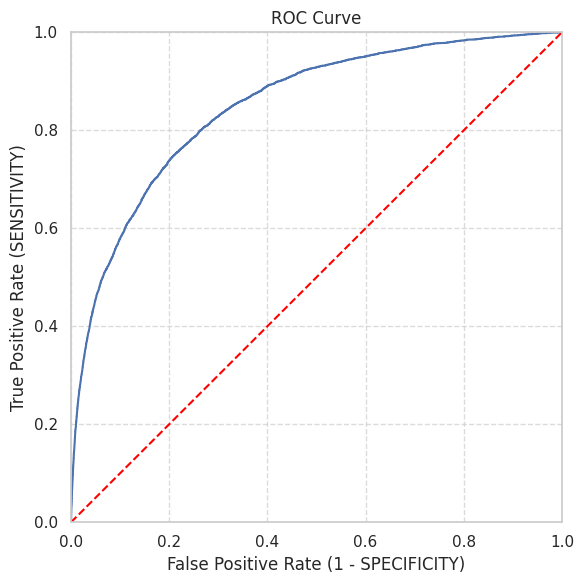

AUC Score: 0.8497292336338408


In [202]:
#here a built in imputer is used to eliminate NANs- why is it needed? didnt we already eliminate them? TO CHECK
imputer = SimpleImputer(strategy='mean')
X_train_array_lr = imputer.fit_transform(X_train_scaled)
X_test_array_lr = imputer.transform(X_test_scaled)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_array_lr, y_train_array)

# Predict probabilities on train set
lr_probs = model.predict_proba(X_train_array_lr)[:, 1]
fpr_lr, tpr_lr, thresh = roc_curve(y_train,lr_probs )
plot_roc_curve(fpr_lr,tpr_lr)
print('AUC Score:', (roc_auc_score(y_train, lr_probs)))


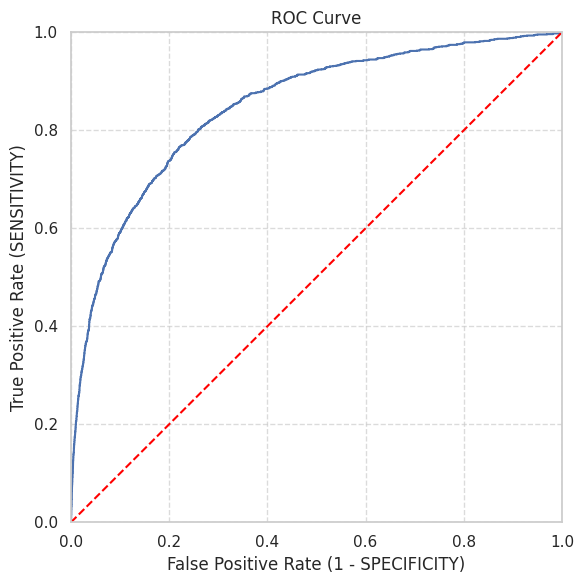

AUC Score: 0.8483039352470839
Threshold: 0.082, Sensitivity: 0.701
Specificity: 0.8312
Flagged as risky: 20.4% of all customers
TP: 960, FP: 3293, TN: 16214, FN: 409
Total flagged: 4253
Actual defaults in test set: 1369


In [203]:
# predict probabilities on test set
lr_scores_proba = model.predict_proba(X_test_array_lr)
lr_preds = lr_scores_proba[:, 1]

lr_fpr, lr_tpr, thresholds = roc_curve(y_test, lr_preds)
plot_roc_curve(lr_fpr, lr_tpr)
print('AUC Score:', roc_auc_score(y_test, lr_preds))

# Find threshold that gives sensitivity >= 0.7
best_thresh = None
for thresh, sens in zip(thresholds, lr_tpr):
    if sens >= 0.70:
        best_thresh = thresh
        print(f"Threshold: {thresh:.3f}, Sensitivity: {sens:.3f}")
        break

# Apply threshold
y_pred = (lr_preds >= best_thresh).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)

print(f"Specificity: {specificity:.4f}")
print(f"Flagged as risky: {(tp + fp) / len(y_test) * 100:.1f}% of all customers")
print(f"TP: {tp}, FP: {fp}, TN: {tn}, FN: {fn}")
print(f"Total flagged: {tp + fp}")
print(f"Actual defaults in test set: {tp + fn}")

## ANN

In [204]:
def initialize_params(layers_size):
    np.random.seed(0)
    params = list()
    for i in range(len(layers_size) - 1):
        # Xavier/Glorot Initialization
        W = np.random.randn(layers_size[i + 1], layers_size[i]) * np.sqrt(
            2 / (layers_size[i + 1] + layers_size[i])
        )
        b = np.zeros((layers_size[i + 1], 1))
        params.append((W, b))
    return params

def ANN(x, params):
    layer = x.T
    for i, (W, b) in enumerate(params):
        layer = W @ layer - b
        if i < len(params) - 1:
            layer = jnp.tanh(layer)
        else:
            layer = jax.nn.sigmoid(layer)
    return layer.T

def loss(x, y, params):
    preds = ANN(x, params)
    # ensure y has the same shape as preds
    y = y.reshape(preds.shape)
    # clip to prevent taking log(0) which causes NaNs
    preds = jnp.clip(preds, 1e-15, 1 - 1e-15)
    # Binary Cross-Entropy
    bce = -jnp.mean(y * jnp.log(preds) + (1 - y) * jnp.log(1 - preds))
    l2 = sum(jnp.sum(W**2) for W, b in params) #performing l2 regularisation
    lambda_reg=1e-4
    bce= bce + lambda_reg * l2
    return bce

In [205]:
input_size = X_train_array.shape[1]
layers_size = [input_size, 64, 32, 1] #shallow network with non uniform size of layers
num_epochs = 500 #more epochs because mse is still decresing
learning_rate_max = 1e-1
learning_rate_min = 1e-2
learning_rate_decay = num_epochs
batch_size = 1000

params = initialize_params(layers_size)

grad = jax.jit(jax.grad(loss, argnums=2)) # params is the 3rd argument
loss_jit = jax.jit(loss)
grad_jit = jax.jit(grad)

n_samples = X_train_array.shape[0]

history_train = list()
history_valid = list()

for epoch in range(num_epochs):
    lr = max(
        learning_rate_min, learning_rate_max * (1 - epoch / learning_rate_decay)
    )
    perm = np.random.permutation(n_samples)
    for i in range(0, n_samples, batch_size):
        batch_idx = perm[i : i + batch_size]
        x_batch = X_train_array[batch_idx]
        y_batch = y_train_array[batch_idx]

        grads = grad_jit(x_batch, y_batch, params)
        params = jax.tree_util.tree_map(lambda p, g: p - lr * g, params, grads)

    history_train.append(loss_jit(X_train_array, y_train_array, params))
    history_valid.append(loss_jit(X_test_array, y_test_array, params))

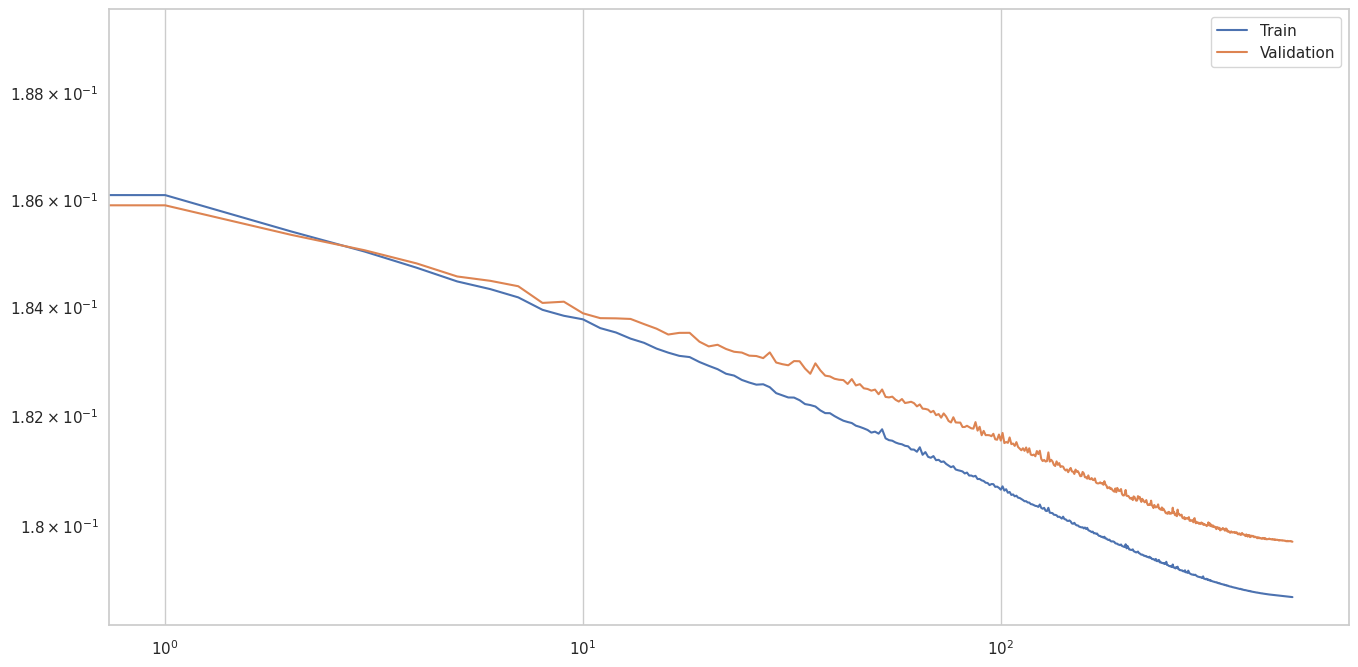

In [206]:
# plotting the loss curves
fig, axs = plt.subplots(1, figsize=(16, 8))
axs.loglog(history_train, label="Train")
axs.loglog(history_valid, label="Validation")
plt.legend()
plt.show()

In [207]:
y_pred_probs = ANN(X_test_array, params)
print('AUC Score:', roc_auc_score(y_test_array, y_pred_probs))

fpr, tpr, thresholds = roc_curve(y_test_array, y_pred_probs)

# Find threshold that gives sensitivity >= 0.7
best_thresh = None
for thresh, sens in zip(thresholds, tpr):
    if sens >= 0.70:
        best_thresh = thresh
        print(f"Threshold: {thresh:.3f}, Sensitivity: {sens:.3f}")
        break

# Apply the threshold here
y_pred = (y_pred_probs >= best_thresh).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test_array, y_pred).ravel()
specificity = tn / (tn + fp)

print(f"Specificity: {specificity:.4f}")
print(f"Flagged as risky: {(tp + fp) / len(y_test_array) * 100:.1f}% of all customers")
print(f"TP: {tp}, FP: {fp}, TN: {tn}, FN: {fn}")
print(f"Total flagged: {tp + fp}")
print(f"Actual defaults in test set: {tp + fn}")

AUC Score: 0.861690843649503
Threshold: 0.092, Sensitivity: 0.701
Specificity: 0.8520
Flagged as risky: 18.4% of all customers
TP: 959, FP: 2888, TN: 16619, FN: 410
Total flagged: 3847
Actual defaults in test set: 1369


## Random Forest

In [ ]:
clf = RandomForestClassifier(random_state=123, max_depth=3, n_estimators=300, class_weight='balanced')
clf.fit(X_train_scaled, y_train)
clf_scores_proba = clf.predict_proba(X_train_scaled)
clf_preds = clf_scores_proba[:, 1]
fpr, tpr, thresh = roc_curve(y_train, clf_preds)
plot_roc_curve(fpr,tpr)
print('AUC Score:', (roc_auc_score(y_train, clf_preds)))

In [ ]:
clf_scores_proba = clf.predict_proba(X_test_scaled)
clf_preds = clf_scores_proba[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, clf_preds)
plot_roc_curve(fpr, tpr)
print('AUC Score:', roc_auc_score(y_test, clf_preds))

# Find threshold that gives sensitivity >= 0.7
best_thresh = None
for thresh, sens in zip(thresholds, tpr):
    if sens >= 0.70:
        best_thresh = thresh
        print(f"Threshold: {thresh:.3f}, Sensitivity: {sens:.3f}")
        break

# Apply threshold
y_pred = (clf_preds >= best_thresh).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)

print(f"Specificity: {specificity:.4f}")
print(f"Flagged as risky: {(tp + fp) / len(y_test) * 100:.1f}% of all customers")
print(f"TP: {tp}, FP: {fp}, TN: {tn}, FN: {fn}")
print(f"Total flagged: {tp + fp}")
print(f"Actual defaults in test set: {tp + fn}")

## XG Boost

In [ ]:
clf = XGBClassifier(random_state=123, n_estimators=150, learning_rate=0.05, max_depth=5)
clf.fit(X_train_scaled, y_train)
clf_scores_proba = clf.predict_proba(X_train_scaled)
# clf_scores_proba is a matrix with 2 columns (first one: probability that the sample
# belongs to class 0, second one: probability that the sample belongs to class 1)
clf_preds = clf_scores_proba[:, 1]
fpr, tpr, thresh = roc_curve(y_train, clf_preds)
# roc_curve returns 3 arrays: False Positive Rate (=FP/(FP+TN)), True Positive Rate (=TP/(TP+FN))
# and the thresholds that have been tested
plot_roc_curve(fpr, tpr)
print('AUC Score:', (roc_auc_score(y_train, clf_preds)))

In [ ]:
clf_scores_proba = clf.predict_proba(X_test_scaled)
clf_preds = clf_scores_proba[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, clf_preds)
plot_roc_curve(fpr, tpr)
print('AUC Score:', roc_auc_score(y_test, clf_preds))

accuracy = accuracy_score(y_test, clf.predict(X_test_scaled))
print("Accuracy: %.2f%%" % (accuracy * 100.0))

# Find threshold that gives sensitivity >= 0.7
best_thresh = None
for thresh, sens in zip(thresholds, tpr):
    if sens >= 0.70:
        best_thresh = thresh
        print(f"Threshold: {thresh:.3f}, Sensitivity: {sens:.3f}")
        break

# Apply threshold to proba scores, not clf.predict()
y_pred = (clf_preds >= best_thresh).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)

print(f"Specificity: {specificity:.4f}")
print(f"Flagged as risky: {(tp + fp) / len(y_test) * 100:.1f}% of all customers")
print(f"TP: {tp}, FP: {fp}, TN: {tn}, FN: {fn}")
print(f"Total flagged: {tp + fp}")
print(f"Actual defaults in test set: {tp + fn}")